In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

In [62]:
np.random.seed(42)

In [63]:
# Normal behavior
cpu = np.random.normal(50, 10, 1000)
memory = np.random.normal(60, 10, 1000)
network = np.random.normal(100, 30, 1000)

In [64]:
# Subtle anomalies (NOT extreme)
cpu_anom = np.random.normal(70, 15, 50)
memory_anom = np.random.normal(75, 15, 50)
network_anom = np.random.normal(150, 50, 50)

In [65]:
# Combine
X_normal = np.column_stack((cpu, memory, network))
X_anomaly = np.column_stack((cpu_anom, memory_anom, network_anom))

X = np.vstack((X_normal, X_anomaly))
y = np.hstack((np.zeros(1000), np.ones(50)))

df = pd.DataFrame(X, columns=["CPU", "Memory", "Network"])
df["Anomaly"] = y

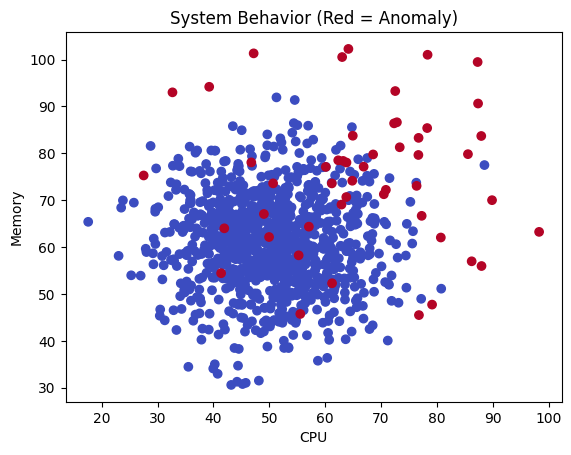

In [66]:
#Plot data
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.xlabel('CPU')
plt.ylabel('Memory')
plt.title('System Behavior (Red = Anomaly)')
plt.show()

In [67]:
#Feature Engineering
# Ratio features
df["cpu_mem_ratio"] = df["CPU"] / (df["Memory"] + 1e-6)
df["cpu_net_ratio"] = df["CPU"] / (df["Network"] + 1e-6)

# Deviation features (use NORMAL data stats)
mean_cpu = df[df["Anomaly"] == 0]["CPU"].mean()
mean_mem = df[df["Anomaly"] == 0]["Memory"].mean()

df["cpu_dev"] = df["CPU"] - mean_cpu
df["memory_dev"] = df["Memory"] - mean_mem

# Time-based behavior (simulated)
df["cpu_diff"] = df["CPU"].diff().fillna(0)
df["memory_diff"] = df["Memory"].diff().fillna(0)

In [68]:
X = df.drop("Anomaly", axis=1)
y = df["Anomaly"]

# Train only on normal
X_train = X[y == 0]
X_test = X
y_test = y

In [69]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X_train_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [71]:
scores = model.decision_function(X_test_scaled)

In [72]:
best_f1 = 0
best_thresh = 0

for p in np.linspace(1, 10, 50):
    thresh = np.percentile(scores, 6)
    preds_temp = (scores < thresh).astype(int)
    
    from sklearn.metrics import f1_score
    f1 = f1_score(y_test, preds_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh
old_f1 = best_f1
print("Best F1:", best_f1)

Best F1: 0.46017699115044247


In [73]:
old_preds = (scores < best_thresh).astype(int)

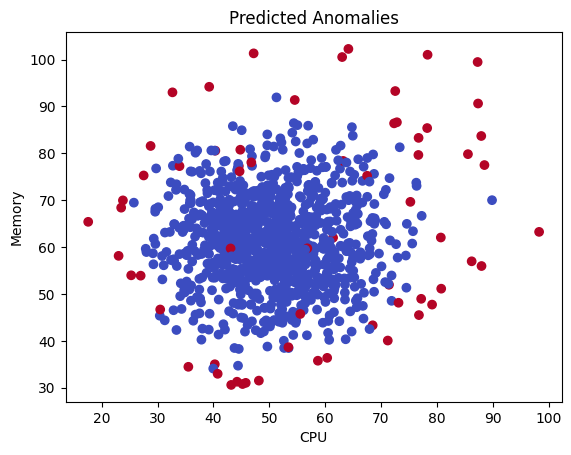

In [74]:
#visualize predictions
plt.scatter(df["CPU"], df["Memory"], c=preds, cmap='coolwarm')
plt.xlabel("CPU")
plt.ylabel("Memory")
plt.title("Predicted Anomalies")
plt.show()

In [75]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      1000
         1.0       0.41      0.52      0.46        50

    accuracy                           0.94      1050
   macro avg       0.69      0.74      0.71      1050
weighted avg       0.95      0.94      0.95      1050



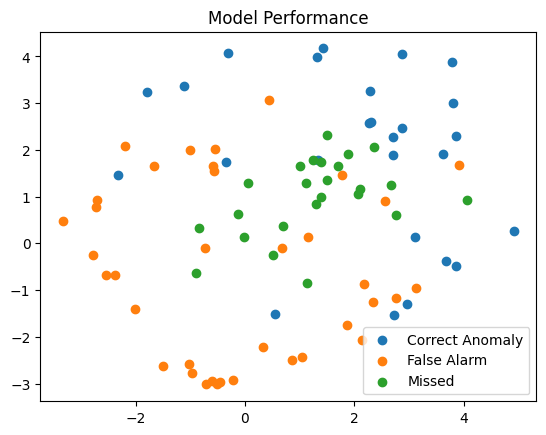

In [76]:
plt.figure()

tp = (preds == 1) & (y_test == 1)
fp = (preds == 1) & (y_test == 0)
fn = (preds == 0) & (y_test == 1)

plt.scatter(X_test_scaled[tp, 0], X_test_scaled[tp, 1], label="Correct Anomaly")
plt.scatter(X_test_scaled[fp, 0], X_test_scaled[fp, 1], label="False Alarm")
plt.scatter(X_test_scaled[fn, 0], X_test_scaled[fn, 1], label="Missed")

plt.legend()
plt.title("Model Performance")
plt.show()

In [77]:
for i in range(len(preds)):
    if preds[i] == 1:
        severity = "HIGH" if scores[i] < np.percentile(scores, 1) else "MEDIUM"
        
        print(f"""
🚨 ALERT: {severity}
CPU: {df.iloc[i]['CPU']:.2f}
Memory: {df.iloc[i]['Memory']:.2f}
Network: {df.iloc[i]['Network']:.2f}
Score: {scores[i]:.4f}
-----------------------
""")


🚨 ALERT: HIGH
CPU: 44.56
Memory: 77.28
Network: 9.41
Score: -0.0985
-----------------------


🚨 ALERT: MEDIUM
CPU: 68.52
Memory: 43.31
Network: 70.79
Score: -0.0182
-----------------------


🚨 ALERT: MEDIUM
CPU: 48.14
Memory: 31.51
Network: 95.88
Score: -0.0448
-----------------------


🚨 ALERT: MEDIUM
CPU: 23.80
Memory: 69.96
Network: 81.47
Score: -0.0696
-----------------------


🚨 ALERT: MEDIUM
CPU: 44.82
Memory: 80.77
Network: 31.11
Score: -0.0433
-----------------------


🚨 ALERT: MEDIUM
CPU: 45.79
Memory: 31.04
Network: 72.94
Score: -0.0642
-----------------------


🚨 ALERT: MEDIUM
CPU: 61.43
Memory: 62.01
Network: 23.13
Score: -0.0197
-----------------------


🚨 ALERT: MEDIUM
CPU: 40.25
Memory: 35.01
Network: 66.66
Score: -0.0276
-----------------------


🚨 ALERT: MEDIUM
CPU: 77.20
Memory: 48.96
Network: 100.20
Score: -0.0445
-----------------------


🚨 ALERT: HIGH
CPU: 88.53
Memory: 77.50
Network: 99.98
Score: -0.0882
-----------------------


🚨 ALERT: MEDIUM
CPU: 73.15
Memory

In [78]:
#Adding features
df["cpu_roll_mean"] = df["CPU"].rolling(5).mean().fillna(method='bfill')
df["memory_roll_mean"] = df["Memory"].rolling(5).mean().fillna(method='bfill')

df["cpu_roll_std"] = df["CPU"].rolling(5).std().fillna(0)

#Spike Detection (Critical)
df["cpu_spike"] = df["CPU"] - df["cpu_roll_mean"]
df["memory_spike"] = df["Memory"] - df["memory_roll_mean"]

#Interaction Features
df["cpu_memory_product"] = df["CPU"] * df["Memory"]
df["network_memory_ratio"] = df["Network"] / (df["Memory"] + 1e-6)

#Z-Score Features
df["cpu_z"] = (df["CPU"] - df["CPU"].mean()) / df["CPU"].std()
df["memory_z"] = (df["Memory"] - df["Memory"].mean()) / df["Memory"].std()

C:\Users\SUYASH\AppData\Local\Temp\ipykernel_19112\3485322962.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["cpu_roll_mean"] = df["CPU"].rolling(5).mean().fillna(method='bfill')
C:\Users\SUYASH\AppData\Local\Temp\ipykernel_19112\3485322962.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["memory_roll_mean"] = df["Memory"].rolling(5).mean().fillna(method='bfill')


In [79]:
df = df.fillna(0)

In [80]:
#Using isolation forest
model = IsolationForest(
    n_estimators=200,   # increase trees
    contamination=0.05,
    random_state=42
)

model.fit(X_train_scaled)

,n_estimators,200
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [81]:
scores = model.decision_function(X_test_scaled)

In [82]:
best_f1 = 0

for p in np.linspace(1, 10, 50):
    thresh = np.percentile(scores, p)
    preds_temp = (scores < thresh).astype(int)
    
    from sklearn.metrics import f1_score
    f1 = f1_score(y_test, preds_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

In [83]:
print("Old F1:", old_f1)
print("New F1:", best_f1)

Old F1: 0.46017699115044247
New F1: 0.5106382978723404


In [84]:
new_preds = (scores < best_thresh).astype(int)

In [85]:
print("===== OLD MODEL =====")
print(classification_report(y_test, old_preds))

print("\n===== NEW MODEL =====")
print(classification_report(y_test, new_preds))

===== OLD MODEL =====
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97      1000
         1.0       0.41      0.52      0.46        50

    accuracy                           0.94      1050
   macro avg       0.69      0.74      0.71      1050
weighted avg       0.95      0.94      0.95      1050


===== NEW MODEL =====
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      1000
         1.0       0.55      0.48      0.51        50

    accuracy                           0.96      1050
   macro avg       0.76      0.73      0.74      1050
weighted avg       0.95      0.96      0.95      1050



In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_vis = pca.fit_transform(X_test_scaled)

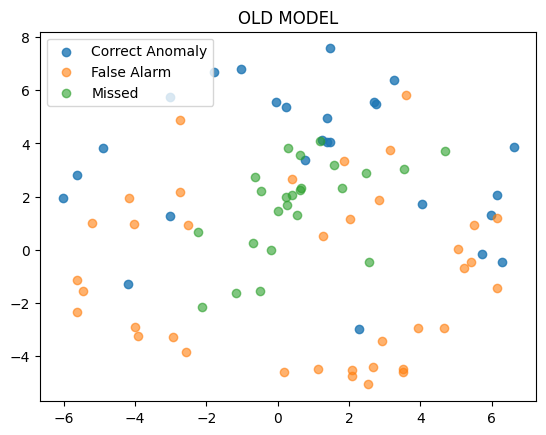

In [88]:
import matplotlib.pyplot as plt

plt.figure()

tp_old = (old_preds == 1) & (y_test == 1)
fp_old = (old_preds == 1) & (y_test == 0)
fn_old = (old_preds == 0) & (y_test == 1)

plt.scatter(X_vis[tp_old, 0], X_vis[tp_old, 1], label="Correct Anomaly", alpha=0.8)
plt.scatter(X_vis[fp_old, 0], X_vis[fp_old, 1], label="False Alarm", alpha=0.6)
plt.scatter(X_vis[fn_old, 0], X_vis[fn_old, 1], label="Missed", alpha=0.6)

plt.title("OLD MODEL")
plt.legend()
plt.show()

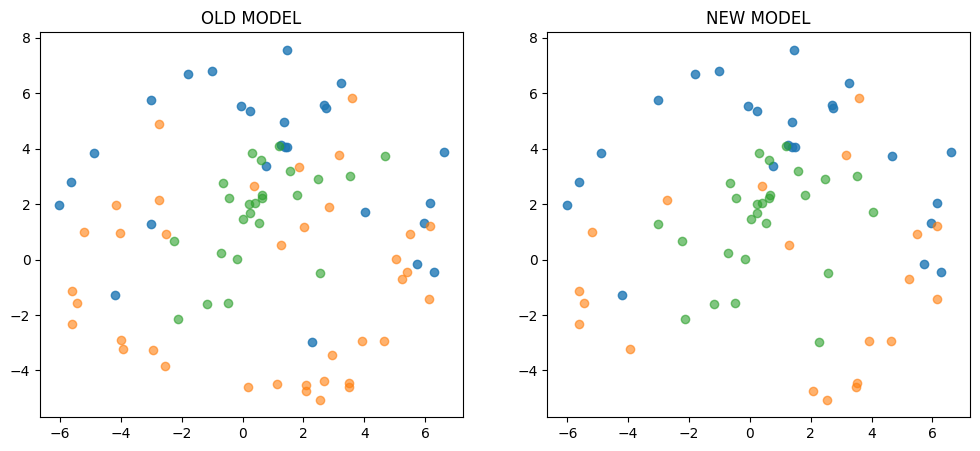

In [90]:
plt.figure(figsize=(12, 5))

# OLD
plt.subplot(1, 2, 1)
plt.scatter(X_vis[tp_old, 0], X_vis[tp_old, 1], alpha=0.8)
plt.scatter(X_vis[fp_old, 0], X_vis[fp_old, 1], alpha=0.6)
plt.scatter(X_vis[fn_old, 0], X_vis[fn_old, 1], alpha=0.6)
plt.title("OLD MODEL")

# NEW
tp_new = (new_preds == 1) & (y_test == 1)
fp_new = (new_preds == 1) & (y_test == 0)
fn_new = (new_preds == 0) & (y_test == 1)
plt.subplot(1, 2, 2)
plt.scatter(X_vis[tp_new, 0], X_vis[tp_new, 1], alpha=0.8)
plt.scatter(X_vis[fp_new, 0], X_vis[fp_new, 1], alpha=0.6)
plt.scatter(X_vis[fn_new, 0], X_vis[fn_new, 1], alpha=0.6)
plt.title("NEW MODEL")

plt.show()

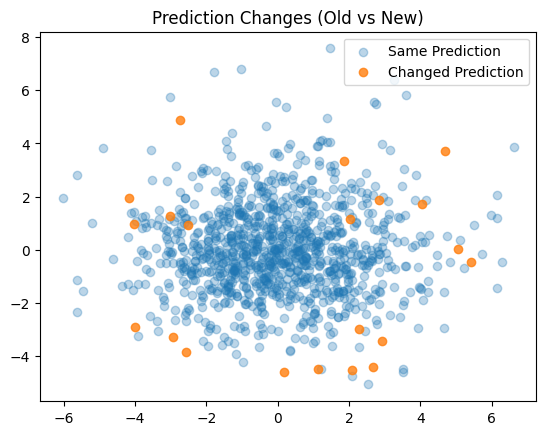

In [91]:
changed = old_preds != new_preds

plt.figure()
plt.scatter(X_vis[~changed, 0], X_vis[~changed, 1], label="Same Prediction", alpha=0.3)
plt.scatter(X_vis[changed, 0], X_vis[changed, 1], label="Changed Prediction", alpha=0.8)

plt.title("Prediction Changes (Old vs New)")
plt.legend()
plt.show()

In [92]:
import joblib

joblib.dump({
    "model": model,
    "scaler": scaler
}, "system_monitor_model.pkl")

['system_monitor_model.pkl']